<a href="https://colab.research.google.com/github/mcPython95/cotton-plant-disease-detection/blob/main/cotton_plant_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Cotton Plant Disease Detection using RESNET152 pretrained model***

---



# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import time
import copy
import os
import random
from PIL import Image
from math import ceil
import warnings
import jax
import torch.multiprocessing as mp

os.environ['OMP_NUM_THREADS'] = '1'
warnings.filterwarnings("ignore", message=".*will create.*worker processes.*")
warnings.filterwarnings("ignore", message="os.fork() was called.*")
mp.set_start_method('spawn', force=True)

# Load dataset


In [ ]:
DataDir = '/content/drive/MyDrive/Cotton disease prediction dataset/8th_sem_project/'

# Preprocessing

In [ ]:

import os
from torchvision import datasets, transforms

def preprocess_images(data_dir):
    transform = transforms.Compose([
        transforms.RandomResizedCrop(256),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(90, scale=(1, 1.5)),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225])
    ])

    processed_images = {}
    for split in ['train', 'val', 'test']:
        processed_images[split] = datasets.ImageFolder(os.path.join(data_dir, split), transform)
    return processed_images


preprocessed_images = preprocess_images(DataDir)


# Data summary

In [ ]:
from collections import Counter

# This loads data for the model
dataloaders = {x: torch.utils.data.DataLoader(preprocessed_images[x], batch_size = 4, shuffle = True, num_workers = 4,pin_memory=True)
               for x in ['train', 'val','test']}

# These are the number of images in both, training and validation sets:
dataset_sizes = {x: len(preprocessed_images[x]) for x in ['train', 'val','test']}

# These refer to the categories in the data:
class_names = preprocessed_images['train'].classes

# Get the number of images in each class for each dataset split
class_counts = {x: Counter(preprocessed_images[x].targets) for x in ['train', 'val', 'test']}

print("Dataset Summary:")
print("-" * 20)


for (phase,size),(classes,counts) in zip(dataset_sizes.items(),class_counts.items()):
    print(f"\n{phase.capitalize()} set: {size} images ")
    for class_name, count in counts.items():
        print(f"{phase}/{class_names[class_name]}: {count} images")


# Print class names
print("\nClass Names:")
print("-" * 20)
print(", ".join(class_names))

Dataset Summary:
--------------------

Train set: 1951 images 
train/diseased cotton leaf: 288 images
train/diseased cotton plant: 815 images
train/fresh cotton leaf: 427 images
train/fresh cotton plant: 421 images

Val set: 334 images 
val/diseased cotton leaf: 65 images
val/diseased cotton plant: 101 images
val/fresh cotton leaf: 80 images
val/fresh cotton plant: 88 images

Test set: 18 images 
test/diseased cotton leaf: 3 images
test/diseased cotton plant: 5 images
test/fresh cotton leaf: 5 images
test/fresh cotton plant: 5 images

Class Names:
--------------------
diseased cotton leaf, diseased cotton plant, fresh cotton leaf, fresh cotton plant


# Visualize dataset

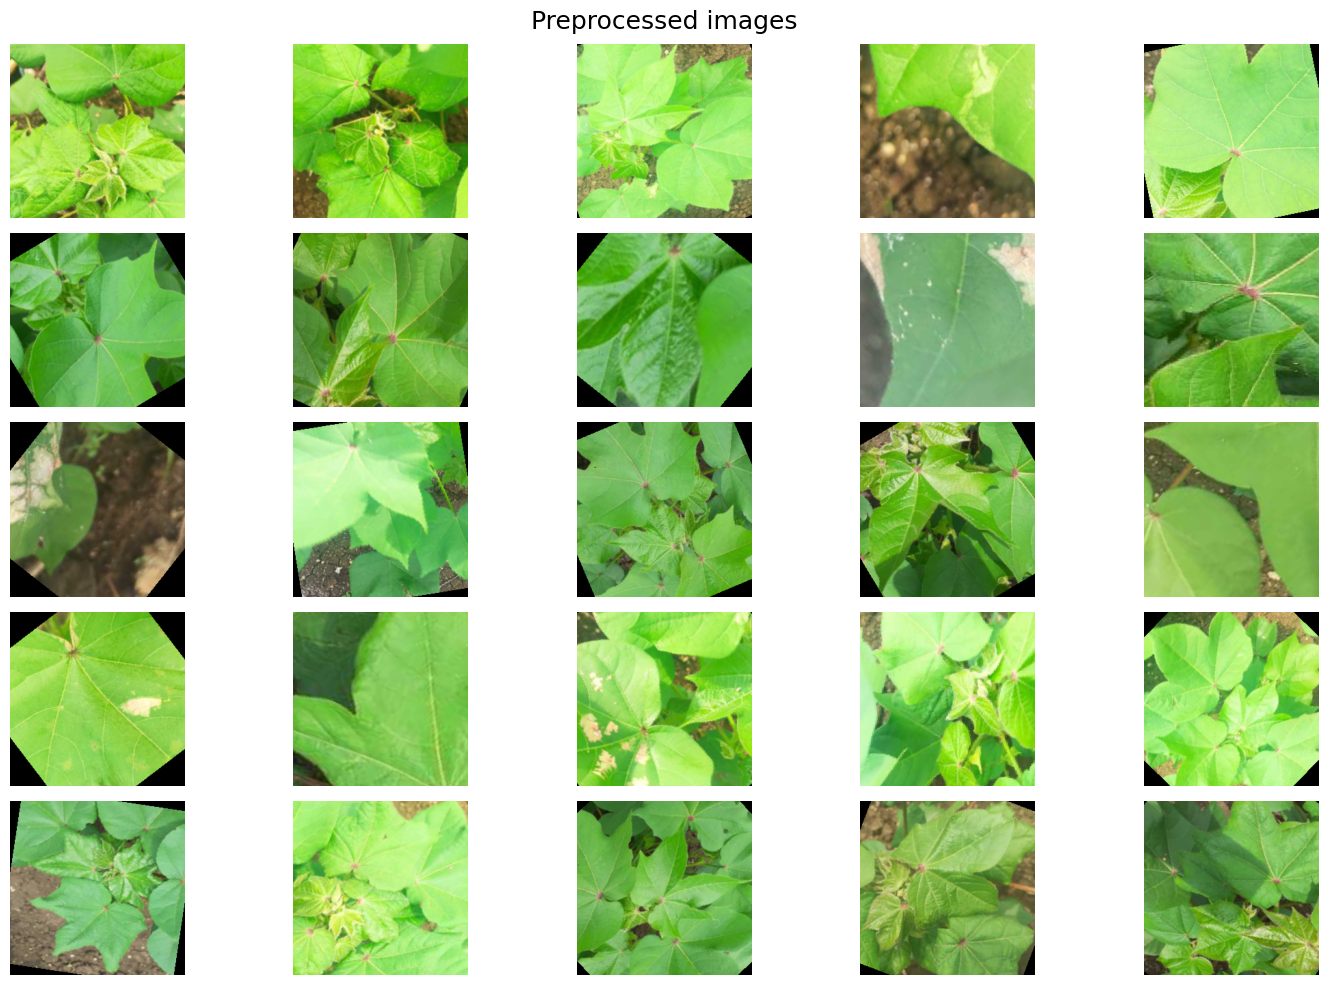

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

def sample_images(dataset, num_samples=25):
    indices = random.sample(range(len(dataset)), num_samples)
    images = [dataset[i][0] for i in indices]
    return torch.stack(images)


def show_images(no_of_images = 25,title = ''):
        plt.figure(figsize=(15,10))
        # Sample 25 images from the training dataset
        inputs = sample_images(preprocessed_images['train'])
        for i in range(no_of_images):
            ax = plt.subplot(int(no_of_images/5), 5, i + 1)
            imshow(inputs[i])
            ax.axis('off')
        plt.suptitle(title, fontsize=18)
        plt.tight_layout()  # Adjust layout for better spacing
        plt.show()


show_images(no_of_images = 25,title  = 'Preprocessed images')

# Setting device parameters

In [ ]:
#If cuda runtime is availble set the device to cuda else cpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Build model

# ResNet152

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt



def initialize_model(num_classes):
    """Initialize the ResNet152 model, criterion, optimizer, and scheduler."""
    model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

    # Modify the final layer
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001,momentum=0.9)
    scheduler = ReduceLROnPlateau(optimizer, mode = 'min', patience=3)
    return model, criterion, optimizer, scheduler

def train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)

    return model, history

def evaluate_model(model, dataloader):
    model.eval()
    running_corrects = 0
    dataset_size = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            dataset_size += labels.size(0)

    accuracy = running_corrects.double() / dataset_size
    print(f'\nTest Accuracy: {accuracy:.4f}')


# Train model

In [ ]:
num_classes = 4
model, criterion, optimizer, scheduler = initialize_model(num_classes)
model, history = train_model(model, criterion, optimizer, scheduler, dataloaders, dataset_sizes, num_epochs = 20)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:01<00:00, 156MB/s]


Epoch 1/20
----------


100%|██████████| 488/488 [02:17<00:00,  3.54it/s]


train Loss: 1.0075 Acc: 0.5782


100%|██████████| 84/84 [00:38<00:00,  2.16it/s]


...

val Loss: 0.0884 Acc: 0.9731
Epoch 20/20
----------


100%|██████████| 488/488 [01:38<00:00,  4.94it/s]


train Loss: 0.1323 Acc: 0.9518


100%|██████████| 84/84 [00:19<00:00,  4.38it/s]

val Loss: 0.0823 Acc: 0.9760


# Evaluate the model

In [ ]:
evaluate_model(model, dataloaders['test'])

100%|██████████| 5/5 [00:18<00:00,  3.80s/it]


Test Accuracy: 1.0000


# Plot history

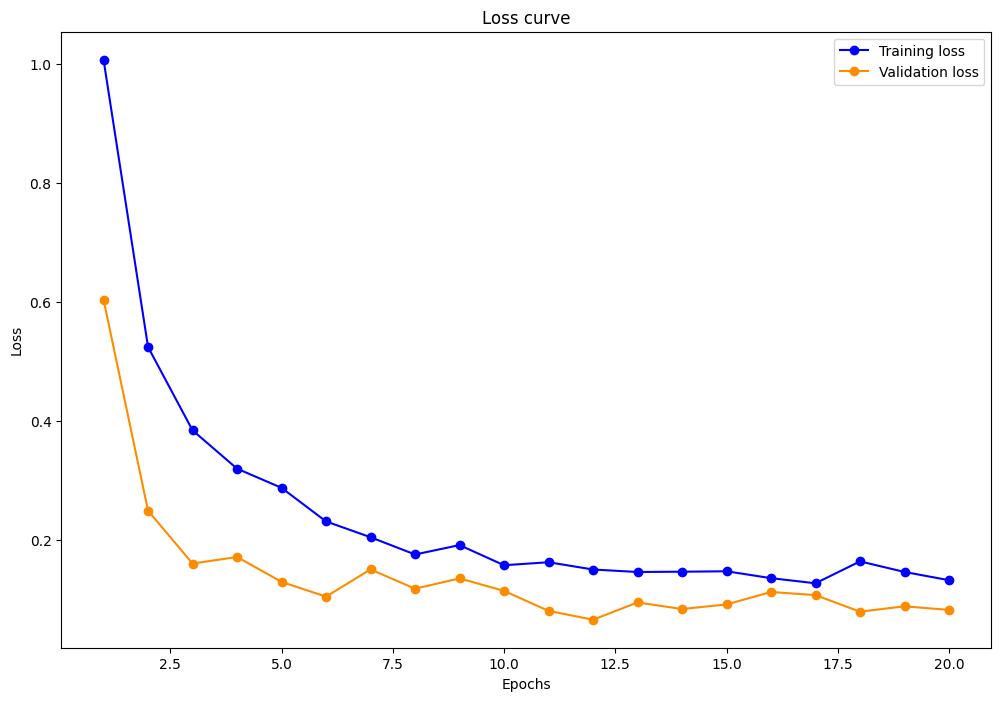

In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs, history['train_loss'], marker = 'o',color = 'blue', label='Training loss')
plt.plot(epochs, history['val_loss'], marker = 'o',color = 'darkorange', label='Validation loss')
plt.title('Loss curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

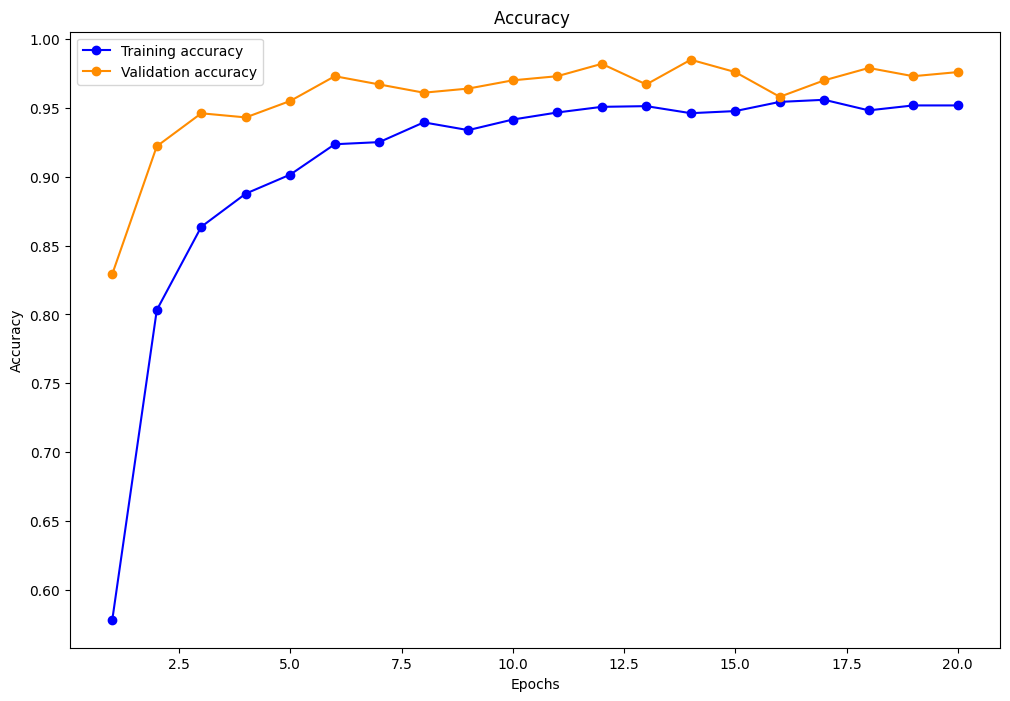

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(epochs, history['train_acc'], marker = 'o',color = 'blue', label='Training accuracy')
plt.plot(epochs, history['val_acc'], marker = 'o',color = 'darkorange', label='Validation accuracy')
plt.title('Accuracy ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

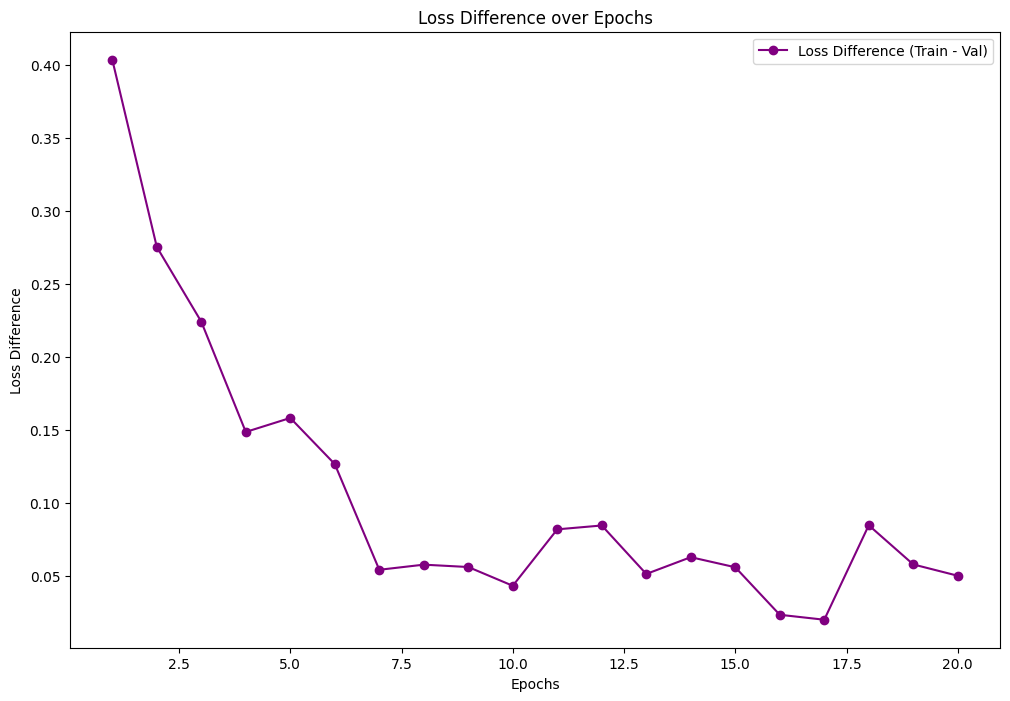

In [ ]:
import matplotlib.pyplot as plt


# Calculate the difference between training and validation loss
loss_diff = [train - val for train, val in zip(history['train_loss'], history['val_loss'])]

# Plotting the loss difference
plt.figure(figsize=(12, 8))
plt.plot(epochs, loss_diff, marker='o', color='purple', label='Loss Difference (Train - Val)')
plt.title('Loss Difference over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Difference')
plt.legend()
plt.show()


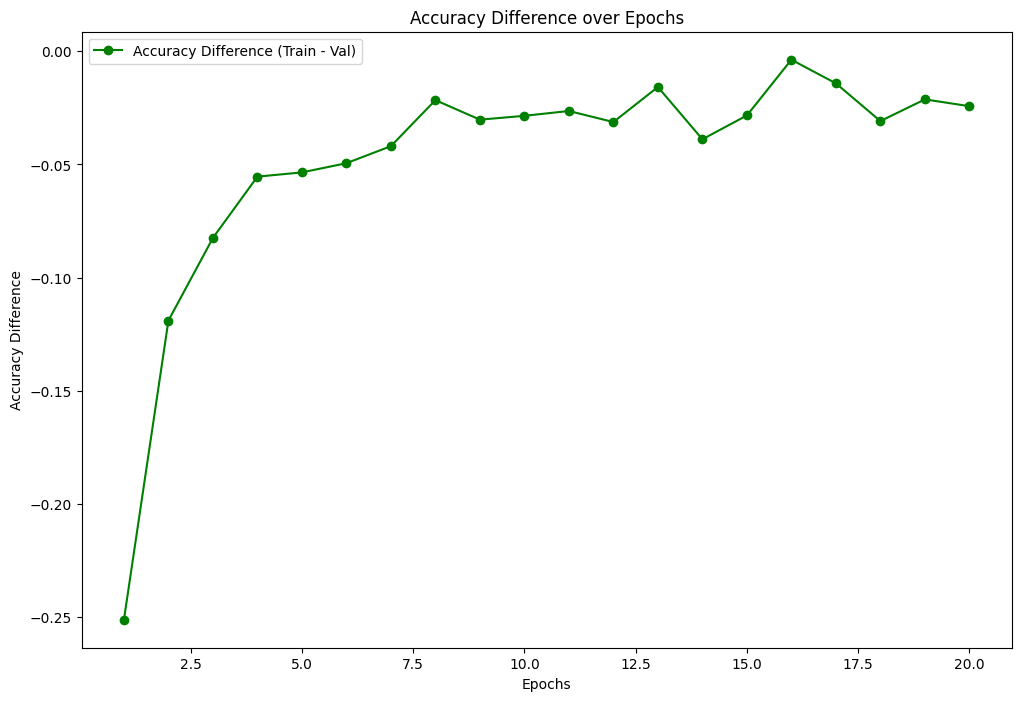

In [ ]:
# Calculate the difference between training and validation accuracy
acc_diff = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]

# Plotting the accuracy difference
plt.figure(figsize=(12, 8))
plt.plot(epochs, acc_diff, marker='o', color='green', label='Accuracy Difference (Train - Val)')
plt.title('Accuracy Difference over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Difference')
plt.legend()
plt.show()


# Save Model

In [ ]:
# #save the trained model in pytorch format
torch.save(model, '/content/drive/MyDrive/Cotton disease prediction dataset/cotton_plant_dis_det_model.pt')

# Load Model

In [ ]:
# Load the entire model from .pt file
loaded_model = torch.load('/content/drive/MyDrive/Cotton disease prediction dataset/cotton_plant_dis_det_model.pt',map_location=torch.device('cpu'),weights_only=False)

# Predictions

# Predict images



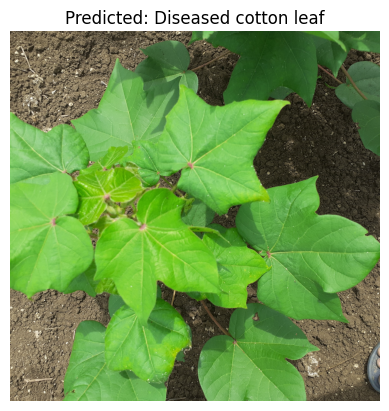

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import torch

def predict_image(model, image_path, device, class_names):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Load the image
    original_image = Image.open(image_path).convert('RGB')

    # Preprocess the image
    image = transform(original_image)
    image_tensor = image.unsqueeze(0)  # Add a batch dimension

    model.to(device)
    model.eval()

    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        _, preds = torch.max(outputs, 1)

    pred_class = class_names[preds.item()]

    return pred_class, original_image

def imshow(image, title=None):
    """Display PIL image."""
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis('off')  # Hide axes for better visualization
    plt.show()
    print()

image_path = '/content/drive/MyDrive/Cotton disease prediction dataset/8th_sem_project/test/diseased cotton plant/dd (328).jpg'
predicted_class, original_image = predict_image(loaded_model, image_path, device, class_names)
imshow(original_image, title=f'Predicted: {predicted_class.capitalize()}')

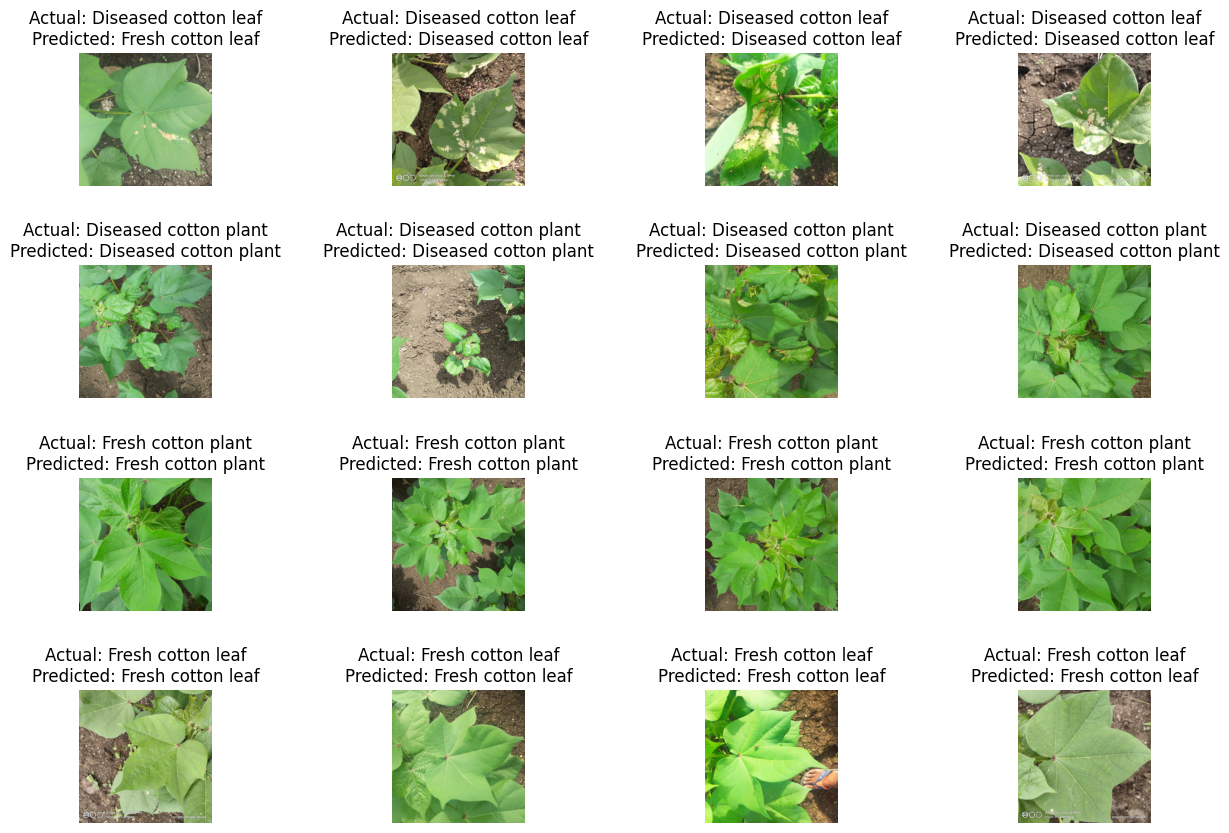

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

random.seed(63235)

# Define the function to list subdirectories and randomly select 4 images from each
def select_random_images(root_dir, num_images=4):
    selected_images = []
    for subdir, _, files in os.walk(root_dir):
        files = [os.path.join(subdir, f) for f in files if f.endswith(('jpg', 'jpeg', 'png'))]
        if files:
            actual_class = os.path.basename(subdir)
            selected_images.extend([(f, actual_class) for f in random.sample(files, min(num_images, len(files)))])
    return selected_images

# Define the function to predict image class
def predict_image(model, image_path, device, class_names):
    image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    predicted_class = class_names[predicted.item()]
    return predicted_class, image

# Function to display images with actual and predicted classes
def display_images_with_predictions(images, actual_classes, predictions):
    plt.figure(figsize=(15, 10))
    for i, (img, actual, pred) in enumerate(zip(images, actual_classes, predictions)):
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(f'Actual: {actual.capitalize()}\nPredicted: {pred.capitalize()}')
        plt.axis('off')
    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    plt.show()

# Define the main function
def main():
    root_dir = '/content/drive/MyDrive/Cotton disease prediction dataset/8th_sem_project/val'
    selected_images = select_random_images(root_dir)

    predictions = []
    images = []
    actual_classes = []
    for image_path, actual_class in selected_images:
        predicted_class, original_image = predict_image(loaded_model, image_path, device, class_names)
        predictions.append(predicted_class)
        images.append(original_image)
        actual_classes.append(actual_class)

    display_images_with_predictions(images, actual_classes, predictions)

# Execute the main function
if __name__ == '__main__':
    main()


# Classification report

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)


def predict(model, dataloaders, device, class_names, num_images=60):
    model.to(device)
    was_training = model.training
    model.eval()
    images_so_far = 1
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            if i < num_images:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.view(-1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
            else:
                break

    model.train(mode=was_training)

    return all_labels,all_preds

y_true, y_pred = predict(loaded_model, dataloaders, device, class_names,num_images = 600)


# Calculate classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
                       precision    recall  f1-score   support

 diseased cotton leaf       1.00      0.94      0.97        65
diseased cotton plant       0.97      0.96      0.97       101
    fresh cotton leaf       0.94      0.94      0.94        80
   fresh cotton plant       0.94      0.99      0.96        88

             accuracy                           0.96       334
            macro avg       0.96      0.96      0.96       334
         weighted avg       0.96      0.96      0.96       334



# Confusion matrix

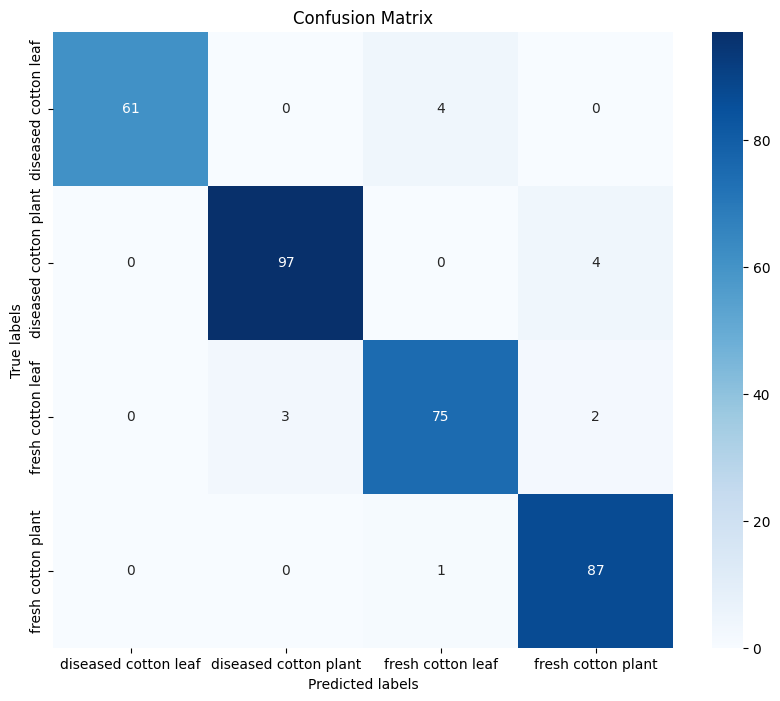

In [ ]:
from sklearn.metrics import  confusion_matrix

# Generate confusion matrix
cm= confusion_matrix(y_true, y_pred)
# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Precision - Recall curve

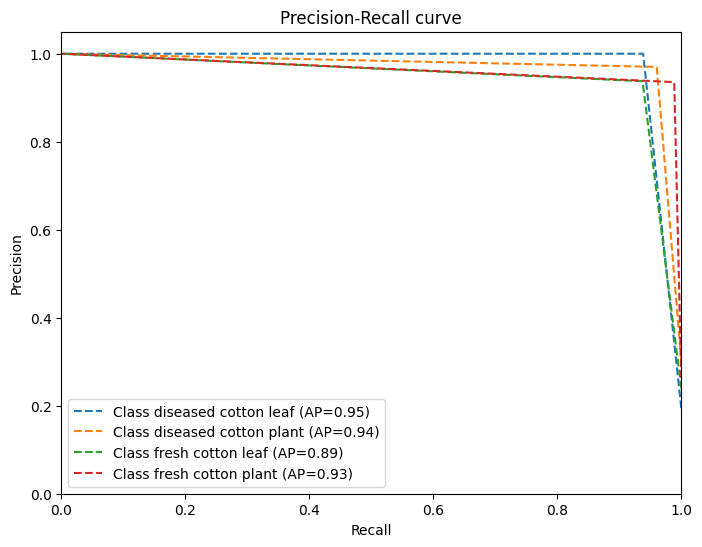

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Convert y_true and y_pred to one-hot encoding
y_true_one_hot = np.eye(len(class_names))[y_true]
y_pred_one_hot = np.eye(len(class_names))[y_pred]

# Calculate precision and recall for each class
precision = dict()
recall = dict()
average_precision = dict()
for i in range(len(class_names)):
    precision[i], recall[i], _ = precision_recall_curve(y_true_one_hot[:, i], y_pred_one_hot[:, i])
    average_precision[i] = average_precision_score(y_true_one_hot[:, i], y_pred_one_hot[:, i])

# Plot precision-recall curves for each class
plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    plt.plot(recall[i], precision[i], label=f'Class {class_names[i]} (AP={average_precision[i]:0.2f})',linestyle ='--' )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall curve')
plt.legend(loc='best')
plt.show()


# Roc curve

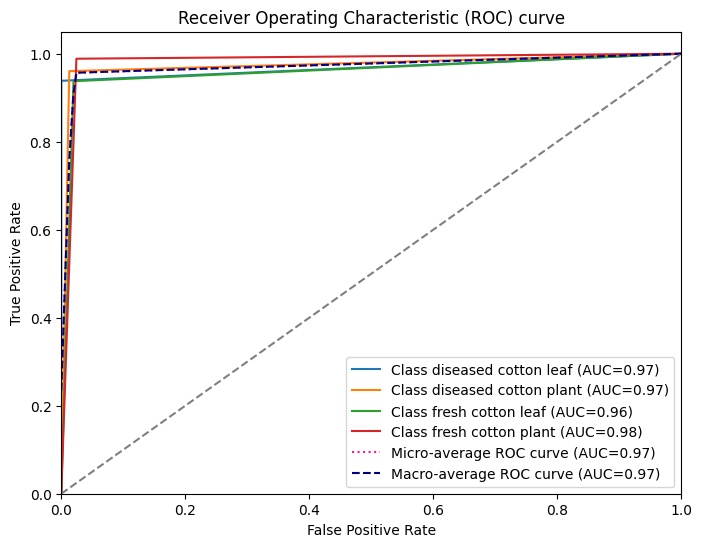

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_pred_one_hot[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Aggregate true positive rates and false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(class_names)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average and compute AUC for micro-average ROC curve
mean_tpr /= len(class_names)
micro_auc = auc(all_fpr, mean_tpr)

# Plot individual class ROC curves
plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC={roc_auc[i]:0.2f})')

# Plot micro-average ROC curve
plt.plot(all_fpr, mean_tpr, label=f'Micro-average ROC curve (AUC={micro_auc:0.2f})', color='deeppink', linestyle=':')

# Compute macro-average ROC curve and AUC
macro_auc = np.mean(list(roc_auc.values()))
macro_fpr = all_fpr
macro_tpr = mean_tpr
plt.plot(macro_fpr, macro_tpr, label=f'Macro-average ROC curve (AUC={macro_auc:0.2f})', color='navy', linestyle='--')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc='best')
plt.show()


# Performance metrics

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix


# Total number of samples
total_samples = np.sum(cm)

accuracy = np.trace(cm) / total_samples
precision = np.mean(np.diag(cm) / np.sum(cm, axis=0))
recall = np.mean(np.diag(cm) / np.sum(cm, axis=1))
f1_score = 2 * (precision * recall) / (precision + recall)
specificity = np.mean([cm[i, i] / (np.sum(cm[:, i]) - cm[i, i] + cm[i, i]) for i in range(cm.shape[0])])
error_rate = 1 - accuracy


print("-" * 40)
print("\tPerformance metrics")
print("-" * 40)

# Print overall metrics
print(f'Accuracy\t\t: {accuracy:.4f}')
print(f'Precision\t\t: {precision:.4f}')
print(f'Recall \t\t\t: {recall:.4f}')
print(f'F1-score\t\t: {f1_score:.4f}')
print(f'Specificity \t\t: {specificity:.4f}')
print(f'ROC-AUC\t\t\t: {macro_auc:.4f}')
print(f'Error Rate \t\t: {error_rate:.4f}')


----------------------------------------
	Performance metrics
----------------------------------------
Accuracy		: 0.9581
Precision		: 0.9607
Recall 			: 0.9562
F1-score		: 0.9585
Specificity 		: 0.9607
ROC-AUC			: 0.9710
Error Rate 		: 0.0419


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
import os
import shutil
from glob import glob
from pathlib import Path

# Set source paths
source_root = "/content/drive/MyDrive/Cotton disease prediction dataset/8th_sem_project"
splits = ['train', 'val', 'test']

# Set destination root for YOLO dataset
yolo_root = "/content/yolo_dataset"

# Define class mapping (your 4 classes)
classes = ['diseased cotton leaf', 'diseased cotton plant', 'fresh cotton leaf', 'fresh cotton plant']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Function to prepare folders
def create_dirs():
    for split in splits:
        os.makedirs(f"{yolo_root}/images/{split}", exist_ok=True)
        os.makedirs(f"{yolo_root}/labels/{split}", exist_ok=True)

# Function to convert dataset
def convert_dataset(split):
    for cls in classes:
        src_folder = os.path.join(source_root, split, cls)
        dest_img_folder = os.path.join(yolo_root, 'images', split)
        dest_lbl_folder = os.path.join(yolo_root, 'labels', split)

        for img_path in glob(f"{src_folder}/*"):
            filename = os.path.basename(img_path)
            dest_img_path = os.path.join(dest_img_folder, filename)
            dest_lbl_path = os.path.join(dest_lbl_folder, Path(filename).with_suffix(".txt"))

            # Copy image
            shutil.copy(img_path, dest_img_path)

            # Write dummy label file
            with open(dest_lbl_path, 'w') as f:
                f.write(f"{class_to_idx[cls]} 0.5 0.5 1.0 1.0\n")

# Run setup and conversion
create_dirs()

for split in splits:
    convert_dataset(split)

print("✅ Dataset converted to YOLO format with dummy labels.")


✅ Dataset converted to YOLO format with dummy labels.


In [ ]:
data_yaml = """
path: /content/yolo_dataset
train: images/train
val: images/val

nc: 4
names: ['diseased cotton leaf', 'diseased cotton plant', 'fresh cotton leaf', 'fresh cotton plant']
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("✅ data.yaml file created.")


✅ data.yaml file created.


In [ ]:
from ultralytics import YOLO

# Load pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train on your dataset
model.train(data='/content/yolo_dataset/data.yaml', epochs=50, imgsz=640)

# Save the trained model
model_path = '/content/yolov8n_custom.pt'
model.save(model_path)

print(f"✅ Training completed and model saved at: {model_path}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 76.2MB/s]


Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrai

100%|██████████| 755k/755k [00:00<00:00, 14.5MB/s]

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      50/50      3.33G    0.02269    0.05635     0.8962         15        640: 100%|██████████| 122/122 [00:41<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:03<00:00,  2.80it/s]

                   all        334        334      0.988      0.989      0.995      0.995



50 epochs completed in 0.658 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:05<00:00,  2.01it/s]


                   all        334        334      0.986      0.998      0.995      0.995
  diseased cotton leaf         65         65      0.969          1      0.995      0.995
 diseased cotton plant        101        101      0.988          1      0.995      0.995
     fresh cotton leaf         80         80          1      0.993      0.995      0.995
    fresh cotton plant         88         88      0.989      0.999      0.995      0.995
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to runs/detect/train
✅ Training completed and model saved at: /content/yolov8n_custom.pt


In [ ]:
from ultralytics import YOLO

model = YOLO('/content/yolov8n_custom.pt')

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/yolov8n_custom.pt")

# Run evaluation (metrics include mAP50, mAP50-95, precision, recall)
metrics = model.val(data="/content/yolo_dataset/data.yaml", split='val')

# Print metrics
print("📊 YOLOv8 Evaluation Metrics:")
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your actual results path
log_path = "/content/runs/detect/train2/results.csv"

# Load and clean the dataframe
df = pd.read_csv(log_path)
df.columns = df.columns.str.strip()  # Remove any leading/trailing whitespace from column names

# Plot Loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['box_loss'], label='Box Loss')
plt.plot(df['epoch'], df['cls_loss'], label='Cls Loss')
plt.plot(df['epoch'], df['dfl_loss'], label='DFL Loss')
plt.title('YOLOv8 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot mAP curves
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
plt.title('YOLOv8 Accuracy (mAP) Curves')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
